In [ ]:
pip install numpy torch pygame


Ep 0
PPO  -> Reward -83.03 | Collisions 26 | Speed 0.81
BASE -> Reward -1315.05 | Collisions 400 | Speed 2.99


Ep 1
PPO  -> Reward 23.49 | Collisions 0 | Speed 1.88
BASE -> Reward -9.26 | Collisions 16 | Speed 2.97


Ep 2
PPO  -> Reward -71.00 | Collisions 24 | Speed 3.09
BASE -> Reward -101.33 | Collisions 0 | Speed 2.98


Ep 3
PPO  -> Reward 3.18 | Collisions 0 | Speed 0.86
BASE -> Reward 54.86 | Collisions 0 | Speed 2.94


Ep 4
PPO  -> Reward 22.53 | Collisions 0 | Speed 1.27
BASE -> Reward -608.69 | Collisions 162 | Speed 2.94


Ep 5
PPO  -> Reward -252.02 | Collisions 64 | Speed 0.56
BASE -> Reward 54.80 | Collisions 0 | Speed 2.96


Ep 6
PPO  -> Reward 22.73 | Collisions 0 | Speed 2.15
BASE -> Reward 54.86 | Collisions 0 | Speed 2.92


Ep 7
PPO  -> Reward -217.02 | Collisions 54 | Speed 0.05
BASE -> Reward -251.01 | Collisions 42 | Speed 2.96


Ep 8
PPO  -> Reward 19.47 | Collisions 0 | Speed 0.93
BASE -> Reward 54.80 | Collisions 0 | Speed 3.02


Ep 9
PPO  -> Reward 22.42 | Co

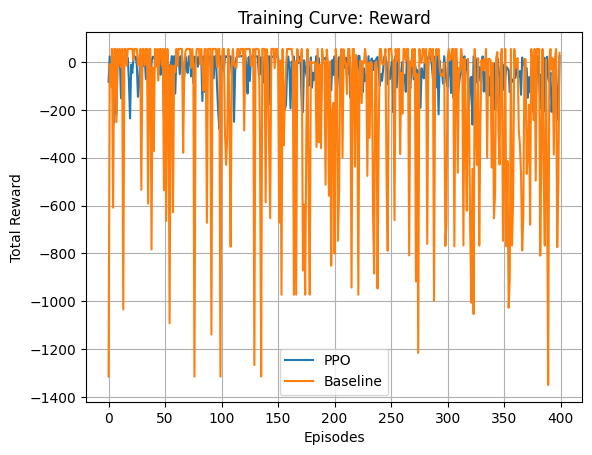

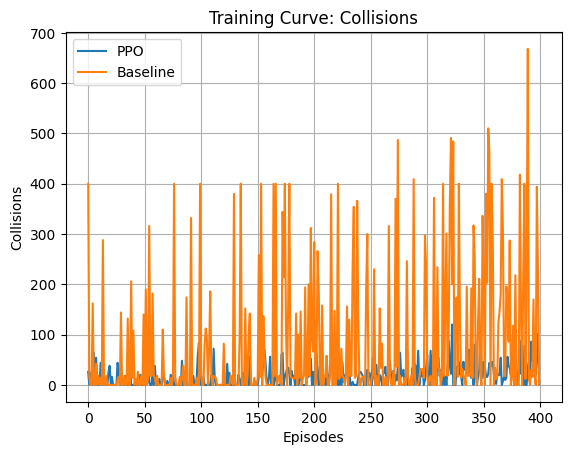

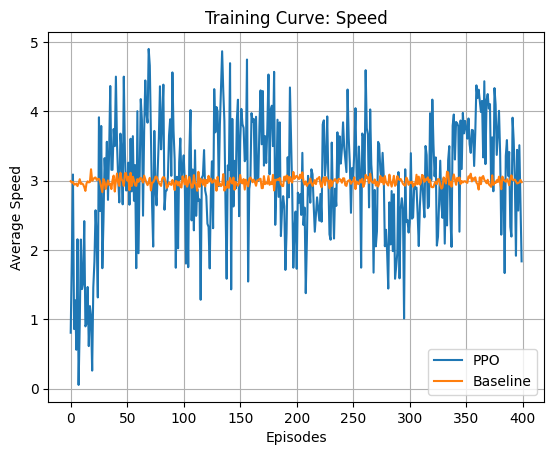


PPO:
Avg Reward     : -74.69
Avg Collisions : 34.56
Avg Speed      : 3.44

BASELINE:
Avg Reward     : -301.44
Avg Collisions : 155.46
Avg Speed      : 2.99



In [12]:
import numpy as np
import pygame
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import matplotlib.pyplot as plt

# ================= CONFIG =================
WIDTH, HEIGHT = 600, 600
LANES_Y = [200, 300, 400]
LANES_X = [200, 300, 400]
DT = 0.1
INTERACTION_RADIUS = 100

# ================= TRAFFIC LIGHT =================
class TrafficLight:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self.timer = 0
        self.state = 0

    def update(self):
        self.timer += 1
        if self.timer > 100:
            self.timer = 0
            self.state = 1 - self.state

# ================= VEHICLE =================
class Vehicle:
    def __init__(self):
        self.x = np.random.choice(LANES_X)
        self.y = np.random.choice(LANES_Y)
        self.v = 0.0
        self.theta = np.random.choice([0, np.pi/2])

    def step(self, action):
        steer, accel = action
        self.theta += steer * 0.2
        self.v += accel * 0.5
        self.v *= 0.98
        self.v = np.clip(self.v, 0, 5)

        self.x += self.v * np.cos(self.theta) * DT * 10
        self.y += self.v * np.sin(self.theta) * DT * 10

# ================= ENV =================
class TrafficEnv:
    def __init__(self, n_agents=5):
        self.n_agents = n_agents
        self.lights = [TrafficLight(x, y) for x in LANES_X for y in LANES_Y]
        self.reset()

    def reset(self):
        self.vehicles = [Vehicle() for _ in range(self.n_agents)]
        self.metrics = {"collisions":0, "violations":0}
        return self._get_obs()

    def _get_obs(self):
      obs = []

      for i, v in enumerate(self.vehicles):
        min_dist = 100
        rel_speed = 0

        for j, u in enumerate(self.vehicles):
            if i != j:
                dx = u.x - v.x
                dy = u.y - v.y
                d = np.hypot(dx, dy)

                if d < min_dist:
                    min_dist = d

                    # relative velocity (CRITICAL)
                    dvx = u.v*np.cos(u.theta) - v.v*np.cos(v.theta)
                    dvy = u.v*np.sin(u.theta) - v.v*np.sin(v.theta)

                    rel_speed = (dx*dvx + dy*dvy) / (d + 1e-5)

        obs.append([
            v.x / WIDTH,
            v.y / HEIGHT,
            v.v / 5,
            np.cos(v.theta),
            np.sin(v.theta),
            min_dist / 100.0,
            rel_speed / 5.0   # Relative Speed
        ])

      return np.array(obs, dtype=np.float32)

    def step(self, actions):
        rewards = []

        for l in self.lights:
            l.update()

        for v,a in zip(self.vehicles, actions):
            v.step(a)

        for i,v in enumerate(self.vehicles):

            reward = 0
            reward += 0.1

            target_speed = 2.5
            reward -= abs(v.v - target_speed) * 0.05

            min_dist = 1e9
            closest_rel_speed = 0
            for j,u in enumerate(self.vehicles):
                if i!=j:
                  dx = u.x - v.x
                  dy = u.y - v.y
                  d = np.hypot(dx, dy)

                  if d < min_dist:
                    min_dist = d
                    # compute relative velocity
                    dvx = u.v*np.cos(u.theta) - v.v*np.cos(v.theta)
                    dvy = u.v*np.sin(u.theta) - v.v*np.sin(v.theta)
                    closest_rel_speed = (dx*dvx + dy*dvy) / (d + 1e-5)

            if min_dist < 50:
              reward -= (50 - min_dist) * 0.05
            # danger zone penalty
            if min_dist < 25:
              reward -= 1.0

            if min_dist < 15:
              reward -= 20
              self.metrics["collisions"] += 1

            if min_dist < 40 and v.v > 2:
              reward -= 0.1

            if min_dist < 60:
              if closest_rel_speed < 0:
                reward -= (-closest_rel_speed) * 0.5

            # ✅ SAFE DISTANCE BONUS
            if min_dist > 50:
              reward += 0.2

            reward -= max(0, v.v - 4.0) * 0.05

            for light in self.lights:
                if abs(v.x-light.x)<15 and abs(v.y-light.y)<15:
                    if light.state==1:
                        reward -= 5
                        self.metrics["violations"] += 1

            rewards.append(reward)

        raw_rewards = np.array(rewards)
        raw_rewards = np.clip(raw_rewards, -10, 10)

        return self._get_obs(), raw_rewards, False, {"raw_rewards": raw_rewards}

# ================= GNN =================
def build_adj(vehicles):
    N = len(vehicles)
    adj = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            if i != j:
                d = np.hypot(
                    vehicles[i].x - vehicles[j].x,
                    vehicles[i].y - vehicles[j].y
                )
                if d < INTERACTION_RADIUS:
                    adj[i][j] = 1 / (d + 1e-5)

    adj = torch.tensor(adj, dtype=torch.float32)

    adj = adj + torch.eye(N)
    deg = adj.sum(1, keepdim=True)
    adj = adj / (deg + 1e-8)

    # ✅ clamp for safety
    adj = torch.clamp(adj, 0, 1)

    return adj

class GNNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim * 2, out_dim)

    def forward(self, x, adj):
        agg = torch.matmul(adj, x)
        h = torch.cat([x, agg], dim=-1)
        return torch.relu(self.fc(h))

class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.gnn1 = GNNLayer(obs_dim, 128)
        self.gnn2 = GNNLayer(128, 128)

        self.actor = nn.Linear(128, act_dim)
        self.log_std = nn.Parameter(torch.zeros(act_dim))
        self.critic = nn.Linear(128, 1)

    def forward(self, x, adj):
        h = self.gnn1(x, adj)
        h = self.gnn2(h, adj)
        return self.actor(h), self.critic(h)

# ================= PPO =================
class PPO:
    def __init__(self, obs_dim, act_dim):
        self.model = ActorCritic(obs_dim, act_dim)
        self.opt = optim.Adam(self.model.parameters(), lr=5e-5)

        self.gamma = 0.99
        self.eps_clip = 0.2
        self.entropy_coef = 0.01

    def get_action(self, obs, adj):
        obs = torch.tensor(obs, dtype=torch.float32)

        mean, value = self.model(obs, adj)

        # ✅ NaN guard
        if torch.isnan(mean).any():
            mean = torch.zeros_like(mean)

        log_std = torch.clamp(self.model.log_std, -2, 2)
        std = torch.exp(log_std)
        std = torch.clamp(std, 0.1, 1.0)
        dist = Normal(mean, std)

        action = dist.sample()
        action = torch.clamp(action, -1, 1)

        return action.detach().numpy(), dist.log_prob(action).sum(-1), value

    def compute_returns(self, rewards):
        R = 0
        returns = []
        for r in reversed(rewards):
            R = r + self.gamma * R
            returns.insert(0, R)
        returns = torch.tensor(returns, dtype=torch.float32)

        # ✅ normalize returns
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        return returns

    def update(self, memory):
        total_loss = 0

        for (states, actions, log_probs, rewards, adj) in memory:

            states = torch.tensor(states, dtype=torch.float32)
            actions = torch.tensor(actions, dtype=torch.float32)
            old_log_probs = torch.tensor(log_probs, dtype=torch.float32)

            # ✅ NaN guard
            if torch.isnan(states).any():
                continue

            returns = self.compute_returns(rewards)

            mean, values = self.model(states, adj)

            # ✅ NaN guard
            if torch.isnan(mean).any():
                continue

            log_std = torch.clamp(self.model.log_std, -2, 2)
            std = torch.exp(log_std)
            std = torch.clamp(std, 0.1, 1.0)
            dist = Normal(mean, std)

            new_log_probs = dist.log_prob(actions).sum(-1)
            entropy = dist.entropy().mean()

            advantages = returns - values.squeeze()
            advantages = (advantages - advantages.mean())/(advantages.std()+1e-8)

            ratio = torch.exp(new_log_probs - old_log_probs)

            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio,1-self.eps_clip,1+self.eps_clip)*advantages

            loss = -torch.min(surr1,surr2).mean() \
                   + 0.5*(returns-values.squeeze()).pow(2).mean() \
                   - self.entropy_coef*entropy

            self.opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.5)
            self.opt.step()

            total_loss += loss.item()

        self.entropy_coef *= 0.999

        return total_loss / max(1, len(memory))

# ================= VIS =================
class Visualizer:
    def __init__(self):
        pygame.init()
        self.screen = pygame.display.set_mode((WIDTH, HEIGHT))

    def draw(self, vehicles, lights):
        self.screen.fill((30,30,30))

        for y in LANES_Y:
            pygame.draw.line(self.screen,(100,100,100),(0,y),(WIDTH,y),3)
        for x in LANES_X:
            pygame.draw.line(self.screen,(100,100,100),(x,0),(x,HEIGHT),3)

        for l in lights:
            color=(0,255,0) if l.state==0 else (255,0,0)
            pygame.draw.circle(self.screen,color,(int(l.x),int(l.y)),6)

        for v in vehicles:
            pygame.draw.circle(self.screen,(0,200,255),(int(v.x),int(v.y)),5)

        pygame.display.flip()

# ================= CURRICULUM =================
def curriculum(ep):
    if ep < 150:
        return 3
    elif ep < 300:
        return 4
    else:
        return 5

# ================= TRAIN =================
agent = PPO(obs_dim=7, act_dim=2)
vis = Visualizer()


# ===== TRAINING LOGS =====
ppo_rewards_log = []
ppo_collisions_log = []
ppo_speed_log = []

baseline_rewards_log = []
baseline_collisions_log = []
baseline_speed_log = []


for ep in range(400):
    n_agents = curriculum(ep)
    env = TrafficEnv(n_agents)

    states = env.reset()
    memory = []
    total_reward = 0

    for t in range(100):
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit(); exit()

        adj = build_adj(env.vehicles)

        actions, log_probs, _ = agent.get_action(states, adj)
        next_states, rewards, _, info = env.step(actions)

        memory.append((states, actions, log_probs.detach().numpy(), rewards, adj))

        states = next_states
        total_reward += info["raw_rewards"].mean()

        vis.draw(env.vehicles, env.lights)

    loss = agent.update(memory)

    avg_speed = np.mean([v.v for v in env.vehicles])

    # ===== BASELINE =====
    baseline_env = TrafficEnv(n_agents)
    b_states = baseline_env.reset()
    b_total_reward = 0

    def rule_policy(states):
        actions = []
        for s in states:
            steer = np.random.normal(0, 0.05)

            if s[2] > 0.6:
                accel = -0.3
            else:
                accel = 0.5

            accel += np.random.normal(0, 0.05)

            actions.append([steer, accel])
        return np.array(actions)

    for t in range(200):
        b_actions = rule_policy(b_states)
        b_states, _, _, b_info = baseline_env.step(b_actions)
        b_total_reward += b_info["raw_rewards"].mean()

    b_avg_speed = np.mean([v.v for v in baseline_env.vehicles])

    print(f"""
Ep {ep}
PPO  -> Reward {total_reward:.2f} | Collisions {env.metrics['collisions']} | Speed {avg_speed:.2f}
BASE -> Reward {b_total_reward:.2f} | Collisions {baseline_env.metrics['collisions']} | Speed {b_avg_speed:.2f}
""")

    # ===== STORE METRICS =====
    ppo_rewards_log.append(total_reward)
    ppo_collisions_log.append(env.metrics["collisions"])
    ppo_speed_log.append(avg_speed)

    baseline_rewards_log.append(b_total_reward)
    baseline_collisions_log.append(baseline_env.metrics["collisions"])
    baseline_speed_log.append(b_avg_speed)

episodes = range(len(ppo_rewards_log))

# ===== REWARD CURVE =====
plt.figure()
plt.plot(episodes, ppo_rewards_log, label="PPO")
plt.plot(episodes, baseline_rewards_log, label="Baseline")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Training Curve: Reward")
plt.legend()
plt.grid()
plt.show()

# ===== COLLISIONS CURVE =====
plt.figure()
plt.plot(episodes, ppo_collisions_log, label="PPO")
plt.plot(episodes, baseline_collisions_log, label="Baseline")
plt.xlabel("Episodes")
plt.ylabel("Collisions")
plt.title("Training Curve: Collisions")
plt.legend()
plt.grid()
plt.show()

# ===== SPEED CURVE =====
plt.figure()
plt.plot(episodes, ppo_speed_log, label="PPO")
plt.plot(episodes, baseline_speed_log, label="Baseline")
plt.xlabel("Episodes")
plt.ylabel("Average Speed")
plt.title("Training Curve: Speed")
plt.legend()
plt.grid()
plt.show()


# ===== FINAL PERFORMANCE (last 50 episodes) =====

N = 50

ppo_final_reward = np.mean(ppo_rewards_log[-N:])
ppo_final_collisions = np.mean(ppo_collisions_log[-N:])
ppo_final_speed = np.mean(ppo_speed_log[-N:])

baseline_final_reward = np.mean(baseline_rewards_log[-N:])
baseline_final_collisions = np.mean(baseline_collisions_log[-N:])
baseline_final_speed = np.mean(baseline_speed_log[-N:])

print(f"""
PPO:
Avg Reward     : {ppo_final_reward:.2f}
Avg Collisions : {ppo_final_collisions:.2f}
Avg Speed      : {ppo_final_speed:.2f}

BASELINE:
Avg Reward     : {baseline_final_reward:.2f}
Avg Collisions : {baseline_final_collisions:.2f}
Avg Speed      : {baseline_final_speed:.2f}
""")